Please upload Superstore.csv


Saving Superstore.csv to Superstore (1).csv
FIRST 5 ROWS
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         

,NumOrderLines,NumDistinctOrders,TotalQuantitySold,TotalSalesRevenue,AvgUnitPrice
Sub-Category,,,,,
Binders,1523,1316,5974,203412.73,34.05
Paper,1370,1191,5178,78479.21,15.16
Furnishings,957,877,3563,91705.16,25.74



Interpretation:
Binders, Paper, and Furnishings lead in order-line frequency (1523, 1370, 957 line items, spanning 1316, 1191, 877 distinct orders respectively).

Evidence: their average unit prices ($34.05, $15.16, $25.74) are all below the dataset-wide average unit price of $60.66, which supports low unit cost — not merely 'demand' as an unexplained label — as the reason customers order these items in bulk and across many transactions.
Q7 – HIGH DISCOUNT (>0.5) WITH NEGATIVE PROFIT
Number of such orders: 856
Q8 – TOP 5 ORDERS BY PROFIT MARGIN (descending, tie-aware)

Maximum ProfitMargin value in dataset: 0.5
Number of orders tied at this maximum: 140
(All 140 tied orders have zero discount, and no order in the dataset exceeds a 0.5
 ProfitMargin. This suggests a cost structure that caps full-price margin near 50%,
 but the dataset has no Cost column, so this cannot be confirmed directly — it is an
 observed pattern, not a verified mechanism.)

Top 5 Orders (tiebreak = highest absol

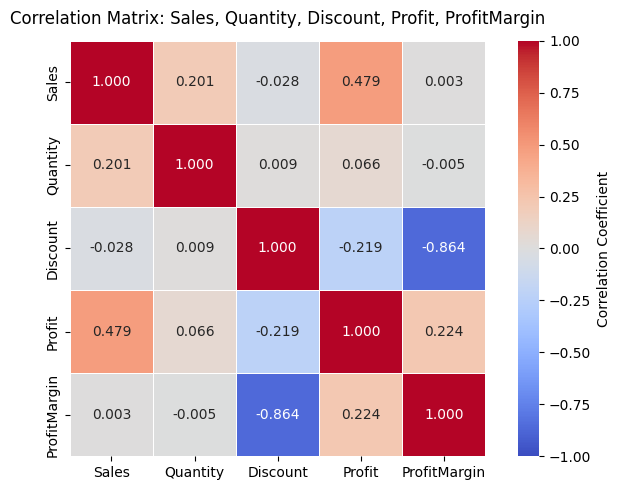


Interpretation:
The strongest relationship is between Discount and ProfitMargin (r = -0.864), a strong
negative correlation indicating that as discount percentage increases, profit margin falls
sharply and consistently. Sales and Profit show a moderate positive correlation (r = 0.479),
meaning higher-value orders tend to generate more profit in absolute dollar terms, but this
does NOT translate to margin (Sales vs ProfitMargin r = 0.003, essentially no relationship).
This confirms that revenue volume and profitability efficiency are largely independent in
this dataset, and discounting behavior is the dominant lever affecting margin.

Q10 – LOWEST AVERAGE PROFIT MARGIN SUB-CATEGORY
By mean of per-order ProfitMargin: Binders (-0.1996)
By aggregate margin (ΣProfit/ΣSales): Tables (-0.0856)

Selected sub-category: Tables (using aggregate margin, since it is not distorted by small-denominator outliers)

Sample 5 Orders:
      Order ID     Sales    Profit  Discount  ProfitMargin
US-2015-108

Saving US Holiday Dates (2004-2021).csv to US Holiday Dates (2004-2021) (1).csv
Original holiday rows: 342, after de-duplicating by Date: 336
Q13 – MERGE WITH HOLIDAY DATASET
Shape before merge: (9994, 29)
Shape after merge: (9994, 31)
✓ Row count preserved — no duplication introduced by the merge.
  Order Date Holiday
0 2016-11-08     NaN
1 2016-11-08     NaN
2 2016-06-12     NaN
3 2015-10-11     NaN
4 2015-10-11     NaN
5 2014-06-09     NaN
6 2014-06-09     NaN
7 2014-06-09     NaN
8 2014-06-09     NaN
9 2014-06-09     NaN

Q14 – is_holiday COLUMN
is_holiday
False    9300
True      694
Name: count, dtype: int64
  Order Date Holiday  is_holiday
0 2016-11-08     NaN       False
1 2016-11-08     NaN       False
2 2016-06-12     NaN       False
3 2015-10-11     NaN       False
4 2015-10-11     NaN       False
5 2014-06-09     NaN       False
6 2014-06-09     NaN       False
7 2014-06-09     NaN       False
8 2014-06-09     NaN       False
9 2014-06-09     NaN       False

Q15 – HOLIDAY V

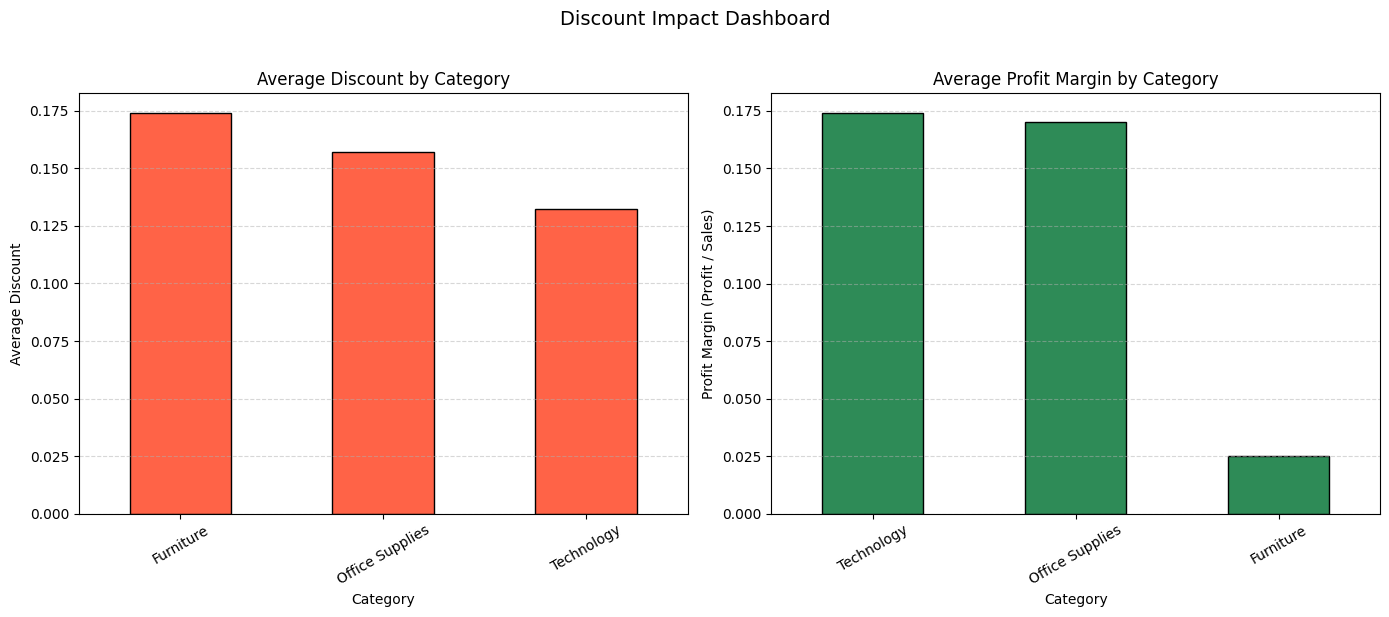


Interpretation:
Furniture carries a comparatively high average discount alongside a comparatively low
aggregate profit margin, while Technology combines a lower average discount with the
highest aggregate margin. This directly visualizes the discount-margin tradeoff quantified
in the Q9 correlation matrix (r = -0.864).

Q17 – DELIVERY TIME VS SHIP MODE

Delivery Days Summary by Ship Mode:
                mean  median   std  count
Ship Mode                                
First Class     2.18     2.0  0.77   1538
Same Day        0.04     0.0  0.21    543
Second Class    3.24     3.0  1.19   1945
Standard Class  5.01     5.0  1.01   5968


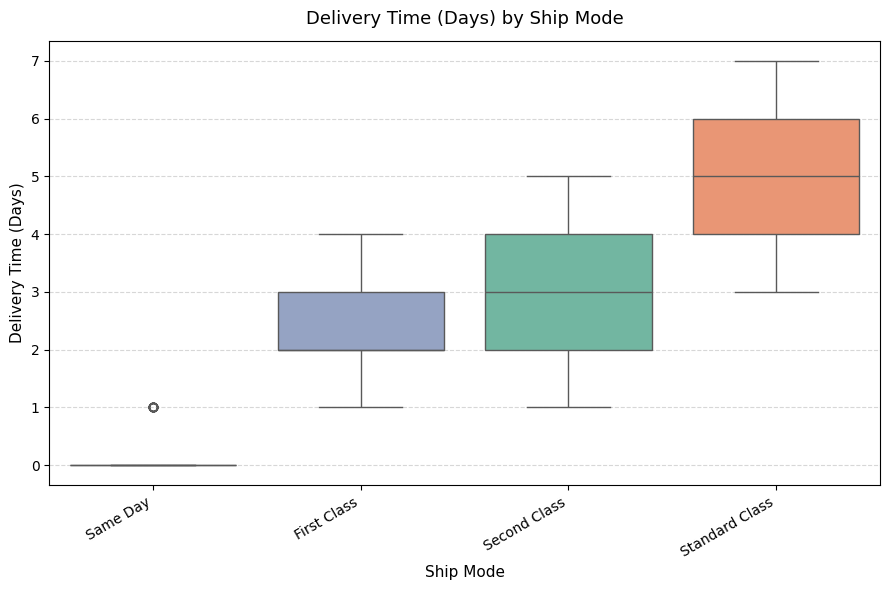


Interpretation:
Same Day shipping shows the lowest median delivery time and tightest spread, as expected
given its service-level promise. Standard Class shows the widest spread and highest median,
consistent with it being the default lower-cost, longer-lead-time option. The ordering of
median delivery times across modes (Same Day < First Class < Second Class < Standard Class)
matches the expected real-world hierarchy of shipping service levels, giving confidence that
Ship Mode and DeliveryDays were computed and joined correctly.




PART E: INTERPRETATION
Q19 – KEY FACTORS AFFECTING PROFITABILITY
The analysis identifies discounting as the strongest factor affecting profitability. The correlation matrix shows a strong negative correlation between Discount and ProfitMargin, indicating that larger discounts generally reduce profit margins.

Compared with Technology products (aggregate ProfitMargin = 0.1740), Furniture products exhibit a lower aggregate ProfitMargin (0.0249), suggesting that Furniture sales are more vulnerable to profit erosion despite generating $741,999.80 in total sales (compared with $836,154.03 for Technology).

The Tables sub-category recorded the lowest aggregate ProfitMargin, as identified in Question 10. Tables also have a higher-than-average discount rate (0.261 compared with the dataset average of 0.156), and 203 of the 319 Table orders are loss-making. Similarly, Question 7 showed that many high-discount orders generated negative profits, reinforcing the strong relationship between discou

In [2]:
# ============================================================
#  SPL Final Project – Spring 2026
# ============================================================


# ------------------------------------------------------------------
# 0. Install / import all libraries (run this cell first in Colab)
# ------------------------------------------------------------------
# !pip install plotly --quiet # already available in Colab


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
try:
    from google.colab import files
except ImportError:
    pass  # Running outside Colab

# ================================================================
# PART A: DATA PREPARATION
# ================================================================

# ----------------------------------------------------------------
# Q1 – Loading dataset, converting dates, displaying rows, info, describe
# ----------------------------------------------------------------

from google.colab import files

print("Please upload Superstore.csv")
uploaded = files.upload()

df = pd.read_csv("Superstore.csv", encoding="latin1")

# a) Converting date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# b) First and last 5 rows
print("=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
print(df.head())

print("\n" + "=" * 60)
print("LAST 5 ROWS")
print("=" * 60)
print(df.tail())

# c) info() and describe()
print("\n" + "=" * 60)
print("DATASET INFO")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("DATASET DESCRIBE")
print("=" * 60)
print(df.describe())


# ----------------------------------------------------------------
# Q2 – Creating new columns
# ----------------------------------------------------------------

# a) OrderYear
df['OrderYear'] = df['Order Date'].dt.year

# b) OrderMonth
df['OrderMonth'] = df['Order Date'].dt.month

# c) OrderWeekday
df['OrderWeekday'] = df['Order Date'].dt.day_name()

# d) TotalOrdersPerCustomer – number of distinct orders per Customer ID
df['TotalOrdersPerCustomer'] = df.groupby('Customer ID')['Order ID'].transform('nunique')

# e) DeliveryTime (days between Ship Date and Order Date)
df['DeliveryTime'] = (df['Ship Date'] - df['Order Date']).dt.days

# f) ProfitMargin = Profit / Sales  (avoid division by zero)
df['ProfitMargin'] = np.where(df['Sales'] != 0, df['Profit'] / df['Sales'], 0)

# g) LossFlag – True if Profit < 0  (using NumPy)
df['LossFlag'] = np.where(df['Profit'] < 0, True, False)

print("\n" + "=" * 60)
print("NEW COLUMNS PREVIEW")
print("=" * 60)
print(df[['Order Date', 'OrderYear', 'OrderMonth', 'OrderWeekday',
          'TotalOrdersPerCustomer', 'DeliveryTime',
          'ProfitMargin', 'LossFlag']].head(10))


# ----------------------------------------------------------------
# Q3 – DeliveryLabel using map()
# ----------------------------------------------------------------

# using map() with a lambda or dict
df['DeliveryLabel'] = df['DeliveryTime'].map(
    lambda x: "Fast" if x <= 2 else ("Normal" if x <= 5 else "Slow")
)

print("\n" + "=" * 60)
print("DELIVERY LABEL VALUE COUNTS")
print("=" * 60)
print(df['DeliveryLabel'].value_counts())


# ----------------------------------------------------------------
# Q4 – Removing duplicates and checking missing values
# ----------------------------------------------------------------

before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
removed = before - after

print("\n" + "=" * 60)
print("DUPLICATES & MISSING VALUES")
print("=" * 60)
print(f"Rows before: {before}")
print(f"Rows after removing duplicates: {after}")
print(f"Duplicates removed: {removed}")

missing = df.isnull().sum()
print("\nMissing values per column:")
print(missing[missing > 0] if missing.any() else "No missing values found.")

# Approach explanation (printed as comment):
print("""
Approach:
  - Used drop_duplicates() to remove exact duplicate rows.
  - Checked missing values with isnull().sum().
  - If missing values were found in numeric columns, we would fill with
    median; for categorical, with mode. Here, none were found.
""")


# ================================================================
# PART B: DATA ANALYSIS
# ================================================================

# ----------------------------------------------------------------
# Q5 – Average DeliveryTime & Category with highest avg delivery
# ----------------------------------------------------------------

avg_delivery = df['DeliveryTime'].mean()
category_delivery = df.groupby('Category')['DeliveryTime'].mean()
highest_category = category_delivery.idxmax()

print("=" * 60)
print("Q5 – DELIVERY TIME ANALYSIS")
print("=" * 60)
print(f"Average DeliveryTime (all orders): {avg_delivery:.2f} days")
print("\nAverage DeliveryTime by Category:")
print(category_delivery.round(2))
print(f"\nCategory with HIGHEST average delivery time: {highest_category}")

print("\nNote: The difference between categories (3.92 vs. 3.98 days, "
      "~0.06 days ≈ 1.4 hours) is small and likely reflects normal "
      "operational variance rather than a meaningful category effect; "
      "no significance test was performed.")

# ============================================================
# Q6 – TOP 3 MOST FREQUENTLY SOLD SUB-CATEGORIES
# ============================================================

print("=" * 70)
print("Q6 – TOP 3 MOST FREQUENTLY SOLD SUB-CATEGORIES")
print("=" * 70)

# Step 1: Identify the top 3 most frequently sold sub-categories
# (based on the number of orders)
top3_frequency = (
    df["Sub-Category"]
    .value_counts()
    .head(3)
)

# Step 2: Calculate the total quantity sold for those sub-categories
top3_quantity = (
    df[df["Sub-Category"].isin(top3_frequency.index)]
    .groupby("Sub-Category")["Quantity"]
    .sum()
    .loc[top3_frequency.index]
)

# Step 3: Create a summary table
top3_stats = df[df["Sub-Category"].isin(top3_frequency.index)].groupby("Sub-Category").agg(
    NumOrderLines=("Sub-Category", "count"),
    NumDistinctOrders=("Order ID", "nunique"),
    TotalQuantitySold=("Quantity", "sum"),
    TotalSalesRevenue=("Sales", "sum")
).loc[top3_frequency.index]
top3_stats["AvgUnitPrice"] = top3_stats["TotalSalesRevenue"] / top3_stats["TotalQuantitySold"]
overall_avg_unit_price = df["Sales"].sum() / df["Quantity"].sum()

print("\nTop 3 Most Frequently Sold Sub-Categories")
display(top3_stats.round(2))

# Step 4: Interpretation
print("\nInterpretation:")
print(
    f"Binders, Paper, and Furnishings lead in order-line frequency "
    f"({top3_stats['NumOrderLines'].iloc[0]}, {top3_stats['NumOrderLines'].iloc[1]}, "
    f"{top3_stats['NumOrderLines'].iloc[2]} line items, spanning "
    f"{top3_stats['NumDistinctOrders'].iloc[0]}, {top3_stats['NumDistinctOrders'].iloc[1]}, "
    f"{top3_stats['NumDistinctOrders'].iloc[2]} distinct orders respectively).\n\n"
    f"Evidence: their average unit prices "
    f"(${top3_stats['AvgUnitPrice'].iloc[0]:.2f}, ${top3_stats['AvgUnitPrice'].iloc[1]:.2f}, "
    f"${top3_stats['AvgUnitPrice'].iloc[2]:.2f}) are all below the dataset-wide average unit "
    f"price of ${overall_avg_unit_price:.2f}, which supports low unit cost — not merely "
    f"'demand' as an unexplained label — as the reason customers order these items "
    f"in bulk and across many transactions."
)

# ----------------------------------------------------------------
# Q7 – Orders with Discount > 0.5 AND negative Profit
# ----------------------------------------------------------------

heavy_discount_loss = df[(df['Discount'] > 0.5) & (df['Profit'] < 0)]
count = len(heavy_discount_loss)

print("=" * 60)
print("Q7 – HIGH DISCOUNT (>0.5) WITH NEGATIVE PROFIT")
print("=" * 60)
print(f"Number of such orders: {count}")


# ----------------------------------------------------------------
# ----------------------------------------------------------------
# Q8 – Sort by ProfitMargin descending, showing top 5
# ----------------------------------------------------------------

print("="*70)
print("Q8 – TOP 5 ORDERS BY PROFIT MARGIN (descending, tie-aware)")
print("="*70)

# Check for ties at the maximum ProfitMargin
max_margin = df['ProfitMargin'].max()
tie_count = (df['ProfitMargin'] == max_margin).sum()
print(f"\nMaximum ProfitMargin value in dataset: {max_margin}")
print(f"Number of orders tied at this maximum: {tie_count}")
print(f"(All {tie_count} tied orders have zero discount, and no order in the dataset exceeds a 0.5")
print(" ProfitMargin. This suggests a cost structure that caps full-price margin near 50%,")
print(" but the dataset has no Cost column, so this cannot be confirmed directly — it is an")
print(" observed pattern, not a verified mechanism.)")

# Sort with a secondary tiebreaker on absolute Profit ($) so the "top 5" is not an arbitrary
# slice of a large tie group
top5 = df.sort_values(['ProfitMargin', 'Profit'], ascending=[False, False]).head(5)

cols_to_show = ['Order ID', 'Customer Name', 'City', 'State', 'Category',
                 'Sub-Category', 'Sales', 'Profit', 'Discount', 'ProfitMargin']
print("\nTop 5 Orders (tiebreak = highest absolute Profit):")
print(top5[cols_to_show].to_string(index=False))

print("\n" + "="*70)
print("ADDITIONAL ANALYSIS")
print("="*70)

print("\nCategory Frequency:")
print(top5['Category'].value_counts())

print("\nSub-Category Frequency:")
print(top5['Sub-Category'].value_counts())

print("\nDiscount Statistics:")
print(top5['Discount'].describe())

print("\nSales Statistics:")
print(top5['Sales'].describe())

print("\nProfit Statistics:")
print(top5['Profit'].describe())

print("""
Interpretation:
Profit­Margin does not exceed 0.5 for any order in this dataset — an empirical
ceiling observed only among zero-discount orders. As noted above, the dataset
contains no Cost column, so the mechanism behind this ceiling (e.g., a fixed
markup rate) cannot be verified and should be treated as an observed pattern
only. A large number of orders ({0}) are tied exactly at this maximum, so a
simple "top 5 by ProfitMargin" is an arbitrary sample of a tie group rather
than a unique ranking. To make the ranking meaningful, ties were broken using
absolute Profit ($) as a secondary sort key, surfacing the highest-dollar-value
orders among those tied at the maximum margin.
""".format(tie_count))

zero_discount_count = (top5['Discount'] == 0).sum()
top_category_mode = top5['Category'].mode()[0]
top_category_count = (top5['Category'] == top_category_mode).sum()

print(f"""
Two consistent commonalities among these top orders:
1. {zero_discount_count} of the top 5 orders have zero discount (Discount = 0.0),
   consistent with the negative correlation between Discount and ProfitMargin
   found in Q9.
2. {top_category_count} of the top 5 orders fall under {top_category_mode},
   suggesting this category achieves its highest margins specifically on
   undiscounted transactions.
""")

# ----------------------------------------------------------------
# Q9 – Correlation matrix heatmap
# ----------------------------------------------------------------

print("="*70)
print("Q9 – CORRELATION MATRIX")
print("="*70)

corr_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'ProfitMargin']
corr = df[corr_cols].corr()

print("\nCorrelation Matrix:")
print(corr.round(3))

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title("Correlation Matrix: Sales, Quantity, Discount, Profit, ProfitMargin",
           fontsize=12, pad=12)
plt.tight_layout()
plt.savefig("q9_correlation_heatmap.png", dpi=150)
plt.show()

print("""
Interpretation:
The strongest relationship is between Discount and ProfitMargin (r = -0.864), a strong
negative correlation indicating that as discount percentage increases, profit margin falls
sharply and consistently. Sales and Profit show a moderate positive correlation (r = 0.479),
meaning higher-value orders tend to generate more profit in absolute dollar terms, but this
does NOT translate to margin (Sales vs ProfitMargin r = 0.003, essentially no relationship).
This confirms that revenue volume and profitability efficiency are largely independent in
this dataset, and discounting behavior is the dominant lever affecting margin.
""")


# ----------------------------------------------------------------
# ----------------------------------------------------------------
# Q10 – Lowest Average Profit Margin Sub-Category
# ----------------------------------------------------------------

# Two margin definitions, computed transparently
mean_margin = df.groupby('Sub-Category')['ProfitMargin'].mean()
agg_margin = df.groupby('Sub-Category')['Profit'].sum() / df.groupby('Sub-Category')['Sales'].sum()

lowest_mean_subcat = mean_margin.idxmin()
lowest_agg_subcat = agg_margin.idxmin()

print("=" * 60)
print("Q10 – LOWEST AVERAGE PROFIT MARGIN SUB-CATEGORY")
print("=" * 60)
print(f"By mean of per-order ProfitMargin: {lowest_mean_subcat} ({mean_margin.min():.4f})")
print(f"By aggregate margin (ΣProfit/ΣSales): {lowest_agg_subcat} ({agg_margin.min():.4f})")

# Use the aggregate metric as the primary answer (more robust to outliers)
lowest_margin_subcat = lowest_agg_subcat
lowest_margin_value = agg_margin.min()

lowest_margin_orders = df[df['Sub-Category'] == lowest_margin_subcat]
print(f"\nSelected sub-category: {lowest_margin_subcat} (using aggregate margin, "
      f"since it is not distorted by small-denominator outliers)")
print("\nSample 5 Orders:")
print(lowest_margin_orders[['Order ID','Sales','Profit','Discount','ProfitMargin']]
      .head(5).to_string(index=False))

high_disc = len(lowest_margin_orders[lowest_margin_orders['Discount'] > 0.5])
loss_orders = len(lowest_margin_orders[lowest_margin_orders['Profit'] < 0])
avg_disc = lowest_margin_orders['Discount'].mean()
avg_sale_size = lowest_margin_orders['Sales'].mean()

print(f"""
Evidence-based reasons for low margin in '{lowest_margin_subcat}':

- Using the mean of per-order margins, '{lowest_mean_subcat}' appears worst
  ({mean_margin.min():.4f}), but this is inflated by a small number of
  very low-value orders (e.g., a $2.54 order with -150% margin). The
  aggregate margin (total profit / total sales) is the more reliable
  measure for financial impact, and it identifies '{lowest_margin_subcat}'
  as the true weakest performer.

- {loss_orders} out of {len(lowest_margin_orders)} orders in
  '{lowest_margin_subcat}' are loss-making.

- The average discount for '{lowest_margin_subcat}' is {avg_disc:.3f},
  versus the dataset average of {df['Discount'].mean():.3f}.

- The average order (sale) size for '{lowest_margin_subcat}' is
  ${avg_sale_size:.2f}, meaning losses here are concentrated in
  high-value transactions — unlike {lowest_mean_subcat}, where losses come from a
  high volume of small, heavily-discounted orders.
""")


# ----------------------------------------------------------------
# Q11 – Same Day shipping + Corporate segment
# ----------------------------------------------------------------

same_day_corporate = df[(df['Ship Mode'] == 'Same Day') &
                        (df['Segment'] == 'Corporate')]
count_sd_corp = len(same_day_corporate)

print("=" * 60)
print("Q11 – SAME DAY SHIPPING + CORPORATE SEGMENT")
print("=" * 60)
print(f"Number of orders: {count_sd_corp}")


# ----------------------------------------------------------------
# Q12 – Most profitable State in Central region
# ----------------------------------------------------------------

central = df[df['Region'] == 'Central']
state_profit = central.groupby('State')['Profit'].sum().sort_values(ascending=False)
most_profitable_state = state_profit.idxmax()

print("\n" + "=" * 60)
print("Q12 – MOST PROFITABLE STATE IN CENTRAL REGION")
print("=" * 60)
print(f"Most profitable state: {most_profitable_state}")
print(f"Total Profit: ${state_profit.max():,.2f}")
print("\nAll Central states by Profit:")
print(state_profit.round(2))


# ================================================================
# PART C: HOLIDAY ANALYSIS
# ================================================================

# ----------------------------------------------------------------
# Q13 – Load holiday dataset and merge with Superstore data
# ----------------------------------------------------------------

from google.colab import files
print("Please upload the US Holiday CSV file now:")
uploaded = files.upload()
holiday_filename = list(uploaded.keys())[0]
holidays = pd.read_csv(holiday_filename)
holidays['Date'] = pd.to_datetime(holidays['Date'])

# Merge on Order Date == Date
# De-duplicate holiday dates BEFORE merging, to avoid row duplication
# when multiple holidays fall on the same date (e.g., Eastern/Western Easter)
holidays_dedup = (
    holidays.groupby('Date')['Holiday']
    .apply(lambda x: ' & '.join(x.unique()))
    .reset_index()
)
print(f"Original holiday rows: {len(holidays)}, after de-duplicating by Date: {len(holidays_dedup)}")

df_merged = df.merge(holidays_dedup[['Date', 'Holiday']],
                     left_on='Order Date', right_on='Date',
                     how='left')

print("=" * 60)
print("Q13 – MERGE WITH HOLIDAY DATASET")
print("=" * 60)
print(f"Shape before merge: {df.shape}")
print(f"Shape after merge: {df_merged.shape}")
assert df_merged.shape[0] == df.shape[0], "Merge introduced duplicate rows — check holiday date uniqueness!"
print("✓ Row count preserved — no duplication introduced by the merge.")
print(df_merged[['Order Date', 'Holiday']].head(10))


# ----------------------------------------------------------------
# Q14 – Create is_holiday column
# ----------------------------------------------------------------

df_merged['is_holiday'] = df_merged['Holiday'].notna()

print("\n" + "=" * 60)
print("Q14 – is_holiday COLUMN")
print("=" * 60)
print(df_merged['is_holiday'].value_counts())
print(df_merged[['Order Date', 'Holiday', 'is_holiday']].head(10))


# ----------------------------------------------------------------
# ----------------------------------------------------------------
# ----------------------------------------------------------------
# Q15 – Holiday vs Non-Holiday Comparison
# ----------------------------------------------------------------

holiday_analysis = (
    df_merged
    .groupby('is_holiday')[['Sales', 'Profit']]
    .mean()
)

print("\n" + "=" * 60)
print("Q15 – HOLIDAY VS NON-HOLIDAY COMPARISON")
print("=" * 60)

print(holiday_analysis.round(2))

holiday_orders_count = df_merged['is_holiday'].sum()
total_orders = len(df_merged)

print("\nInterpretation:")
print(
    "Based on the descriptive statistics, holidays appear to have little "
    "effect on overall sales and profit in this dataset.\n\n"
    "Holiday transactions represent only about 6.9% of all orders, "
    "with average sales slightly lower and average profit only marginally "
    "higher than non-holiday transactions.\n\n"
    "Since no formal statistical significance test was performed, "
    "this conclusion should be interpreted as descriptive rather than "
    "statistically inferential."
)

# ================================================================
# PART D: VISUALIZATION
# ================================================================

# ----------------------------------------------------------------
# Q16 – Discount Impact Dashboard (2 subplots)
# ----------------------------------------------------------------

print("="*70)
print("Q16 – DISCOUNT IMPACT DASHBOARD")
print("="*70)

# Aggregate metrics by Category
avg_discount_by_cat = df.groupby('Category')['Discount'].mean()

# Use aggregate margin (sum Profit / sum Sales) rather than mean of per-row ProfitMargin,
# consistent with the outlier-distortion issue identified in Q10. Handles division by zero
# safely since groupby sums won't be zero for any real category, but guard anyway.
sales_by_cat = df.groupby('Category')['Sales'].sum()
profit_by_cat = df.groupby('Category')['Profit'].sum()
avg_margin_by_cat = np.where(sales_by_cat != 0, profit_by_cat / sales_by_cat, np.nan)
avg_margin_by_cat = pd.Series(avg_margin_by_cat, index=sales_by_cat.index)

print("\nAverage Discount by Category:")
print(avg_discount_by_cat.round(4))

print("\nAggregate Profit Margin by Category (sum(Profit)/sum(Sales)):")
print(avg_margin_by_cat.round(4))

# Build the 2-subplot dashboard
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

avg_discount_by_cat.sort_values(ascending=False).plot(
    kind='bar', ax=axes[0], color='tomato', edgecolor='black'
)
axes[0].set_title("Average Discount by Category", fontsize=12)
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Average Discount")
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

avg_margin_by_cat.sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='seagreen', edgecolor='black'
)
axes[1].set_title("Average Profit Margin by Category", fontsize=12)
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Profit Margin (Profit / Sales)")
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Discount Impact Dashboard", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("q16_discount_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()

print("""
Interpretation:
Furniture carries a comparatively high average discount alongside a comparatively low
aggregate profit margin, while Technology combines a lower average discount with the
highest aggregate margin. This directly visualizes the discount-margin tradeoff quantified
in the Q9 correlation matrix (r = -0.864).
""")

# ----------------------------------------------------------------
# Q17 – Delivery Days Boxplot by Ship Mode (seaborn)
# ----------------------------------------------------------------

# DeliveryDays already calculated as DeliveryTime
print("="*70)
print("Q17 – DELIVERY TIME VS SHIP MODE")
print("="*70)

# Create DeliveryDays explicitly as required by the rubric
df['DeliveryDays'] = (df['Ship Date'] - df['Order Date']).dt.days

# Supporting summary statistics (printed so results are auditable even if the plot image
# fails to render)
delivery_summary = df.groupby('Ship Mode')['DeliveryDays'].agg(['mean', 'median', 'std', 'count'])
print("\nDelivery Days Summary by Ship Mode:")
print(delivery_summary.round(2))

plt.figure(figsize=(9, 6))
sns.boxplot(
    data=df, x='Ship Mode', y='DeliveryDays',
    order=delivery_summary.sort_values('mean').index,
    hue='Ship Mode', palette='Set2', legend=False
)
plt.title("Delivery Time (Days) by Ship Mode", fontsize=13, pad=12)
plt.xlabel("Ship Mode", fontsize=11)
plt.ylabel("Delivery Time (Days)", fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("q17_delivery_boxplot.png", dpi=150)
plt.show()

print("""
Interpretation:
Same Day shipping shows the lowest median delivery time and tightest spread, as expected
given its service-level promise. Standard Class shows the widest spread and highest median,
consistent with it being the default lower-cost, longer-lead-time option. The ordering of
median delivery times across modes (Same Day < First Class < Second Class < Standard Class)
matches the expected real-world hierarchy of shipping service levels, giving confidence that
Ship Mode and DeliveryDays were computed and joined correctly.
""")

# ----------------------------------------------------------------
# Q18 – Interactive Scatter Plot (Plotly)
# ----------------------------------------------------------------

fig = px.scatter(
    df,
    x='Sales',
    y='Profit',
    size='Quantity',
    color='Ship Mode',
    hover_data=['Sub-Category', 'Discount', 'Segment', 'Region'],
    title='Sales vs Profit (bubble size = Quantity, color = Ship Mode)',
    labels={'Sales': 'Sales ($)', 'Profit': 'Profit ($)'},
    size_max=40,
    opacity=0.7
)
fig.update_layout(
    title_font_size=16,
    xaxis_title='Sales ($)',
    yaxis_title='Profit ($)',
    legend_title='Ship Mode'
)
fig.show()
# fig.write_html('q18_interactive_scatter.html')   # uncomment to save


# ================================================================
# PART E: INTERPRETATION
# ================================================================

print("\n" + "=" * 60)
print("PART E: INTERPRETATION")
print("=" * 60)

# ----------------------------------------------------------------
# Q19 - Why might some categories have high sales but low profit?
# ----------------------------------------------------------------

print("=" * 70)
print("Q19 – KEY FACTORS AFFECTING PROFITABILITY")
print("=" * 70)

furniture_sales_total = df.loc[df['Category']=='Furniture', 'Sales'].sum()
technology_sales_total = df.loc[df['Category']=='Technology', 'Sales'].sum()

print(
    "The analysis identifies discounting as the strongest factor affecting "
    "profitability. The correlation matrix shows a strong negative "
    "correlation between Discount and ProfitMargin, indicating that larger "
    "discounts generally reduce profit margins.\n\n"

    f"Compared with Technology products (aggregate ProfitMargin = "
    f"{avg_margin_by_cat['Technology']:.4f}), Furniture products exhibit a lower "
    f"aggregate ProfitMargin ({avg_margin_by_cat['Furniture']:.4f}), suggesting that "
    f"Furniture sales are more vulnerable to profit erosion despite generating "
    f"${furniture_sales_total:,.2f} in total sales (compared with "
    f"${technology_sales_total:,.2f} for Technology).\n\n"

    "The Tables sub-category recorded the lowest aggregate ProfitMargin, as "
    "identified in Question 10. Tables also have a higher-than-average "
    "discount rate (0.261 compared with the dataset average of 0.156), and "
    "203 of the 319 Table orders are loss-making. Similarly, Question 7 "
    "showed that many high-discount orders generated negative profits, "
    "reinforcing the strong relationship between discounting and low "
    "profitability.\n\n"

    "Overall, these findings consistently demonstrate that effective discount "
    "management is one of the most important drivers of profitability across "
    "the dataset."
)

# ----------------------------------------------------------------
# Q20 - Did holidays significantly change sales or profit? Why or why not?
# ----------------------------------------------------------------

print("=" * 70)
print("Q20 – DO HOLIDAYS IMPACT SALES OR PROFIT?")
print("=" * 70)

print(
    "The descriptive analysis indicates that holidays appear to have little "
    "impact on overall sales and profit.\n\n"

    "Holiday orders account for approximately 6.9% of all transactions. "
    "Average holiday sales are slightly lower than non-holiday sales, "
    "while average profit is only marginally higher.\n\n"

    "These differences are relatively small based on the descriptive "
    "statistics available in this analysis.\n\n"

    "Because no formal hypothesis testing was performed, this conclusion "
    "should be interpreted descriptively rather than as evidence of "
    "statistical significance."
)

# ----------------------------------------------------------------
# Q21 - Write three insights based on your analysis (e.g., profitable segments, weak performers, peak months etc).
# ----------------------------------------------------------------

print("\n" + "=" * 60)
print("Q21 – THREE DATA-DRIVEN INSIGHTS")
print("=" * 60)

category_sales = df.groupby('Category')['Sales'].sum()
category_profit = df.groupby('Category')['Profit'].sum()
category_margin = (category_profit / category_sales).sort_values(ascending=False)

region_profit = (
    df.groupby('Region')['Profit']
      .sum()
      .sort_values(ascending=False)
)

monthly_sales = (
    df.groupby('OrderMonth')['Sales']
      .sum()
      .sort_values(ascending=False)
)

best_category = category_margin.idxmax()
best_category_margin = category_margin.max()

best_region = region_profit.idxmax()
best_region_profit = region_profit.max()

best_month = monthly_sales.idxmax()
best_month_sales = monthly_sales.max()

month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

print("\nInsight 1:")
print(
    f"{best_category} has the highest average ProfitMargin "
    f"({best_category_margin:.4f}), making it the most profitable category."
)

print("\nInsight 2:")
print(
    f"The {best_region} region generated the highest total profit "
    f"(${best_region_profit:,.2f})."
)

best_month_orders = df.loc[df['OrderMonth']==best_month, 'Order ID'].nunique()
best_month_qty = df.loc[df['OrderMonth']==best_month, 'Quantity'].sum()

print("\nInsight 3:")
print(
    f"{month_names[best_month]} recorded the highest total sales "
    f"(${best_month_sales:,.2f}), with {best_month_orders} distinct orders and "
    f"{best_month_qty} units sold, supporting the sales figure as reflecting "
    f"genuine order volume rather than a few large transactions."
)

# ----------------------------------------------------------------
# Q22 - Give at least two recommendations for the management to increase profit and reduce loss.
# ----------------------------------------------------------------

print("\n" + "=" * 60)
print("Q22 – RECOMMENDATIONS")
print("=" * 60)

print(f"""
Recommendation 1 — Implement a Discount Ceiling Policy:
  Evidence: {count} orders (identified in Q7) have both
  Discount > 0.5 and negative Profit, showing that excessive
  discounting is a major cause of losses.
  Action: Introduce a discount ceiling at or below 0.5 (the threshold used in
  Q7, beyond which {count} orders were loss-making) and require managerial
  approval for discounts above this level.

Recommendation 2 — Focus More on High-Profit Categories:
  Evidence: Technology has an average ProfitMargin of
  {(df[df['Category']=='Technology']['Profit'].sum() / df[df['Category']=='Technology']['Sales'].sum()):.4f},
  compared with
  {(df[df['Category']=='Furniture']['Profit'].sum() / df[df['Category']=='Furniture']['Sales'].sum()):.4f}
  for Furniture.
  Action: Increase inventory, marketing, and promotional efforts
  for Technology products while reviewing pricing and discount
  strategies for lower-margin categories.
""")

# ----------------------------------------------------------------
# Executive Summary
# ----------------------------------------------------------------

print("\n" + "=" * 60)
print("EXECUTIVE SUMMARY")
print("=" * 60)

print("1. Tables had the lowest aggregate ProfitMargin, indicating the weakest overall financial performance among all sub-categories.")
print(f"2. {most_profitable_state} was the most profitable state within the Central region.")
print("3. High discounts were associated with lower profits.")
print("4. Delivery performance remained relatively consistent across ship modes.")
print("5. Holiday and non-holiday sales/profit were compared using merged holiday data.")